Dataset Shape: (24042, 15)

Missing Values:
 timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

Target Distribution:
 failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

==================== Logistic Regression ====================
              precision    recall  f1-score   support

  No Failure       0.98      0.91      0.95      4097
     Failure       0.64      0.89      0.75       712

    accuracy                           0.91      4809
   macro avg       0.81      0.90      0.85      4809
weighted avg       0.93      0.91    

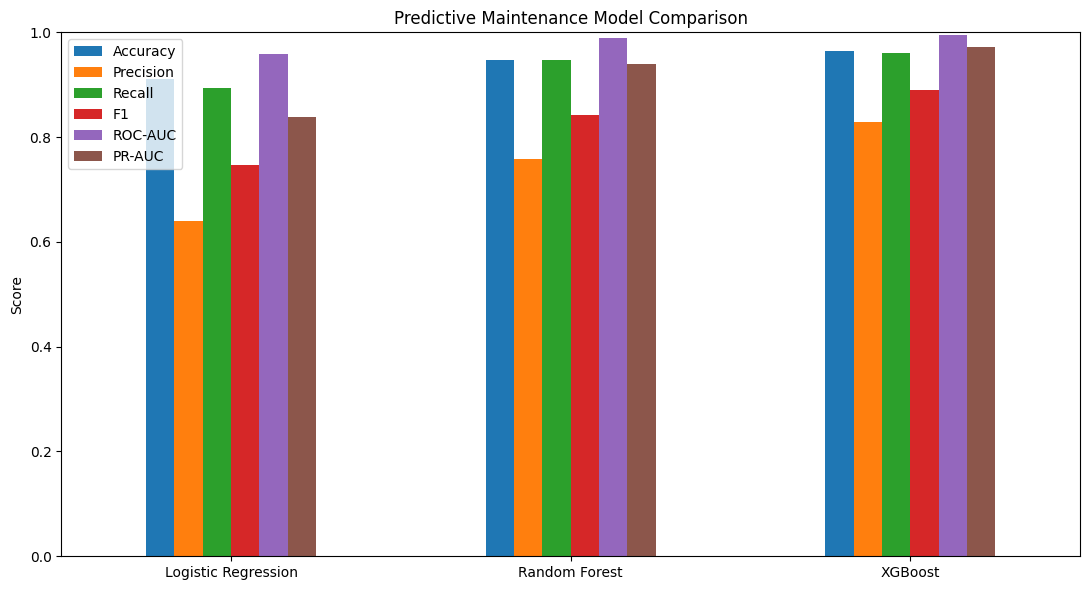


Random Forest - Top Features:
num__temperature_motor           0.267842
num__rpm                         0.200920
num__current_phase_avg           0.170863
num__vibration_rms               0.159659
num__hours_since_maintenance     0.059290
num__pressure_level              0.053047
cat__operating_mode_normal       0.016521
cat__operating_mode_idle         0.015435
cat__machine_type_Pump           0.012429
cat__machine_type_Robotic Arm    0.011793
dtype: float64


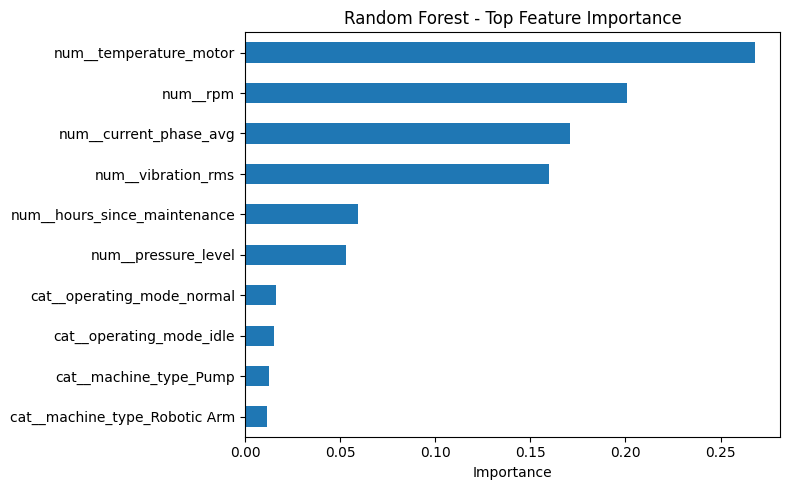


XGBoost - Top Features:
num__temperature_motor           0.156896
cat__operating_mode_normal       0.134550
num__rpm                         0.115346
cat__operating_mode_peak         0.101175
cat__operating_mode_idle         0.092330
num__vibration_rms               0.067592
cat__machine_type_Robotic Arm    0.058388
num__current_phase_avg           0.056366
cat__machine_type_CNC            0.050361
cat__machine_type_Pump           0.045832
dtype: float32


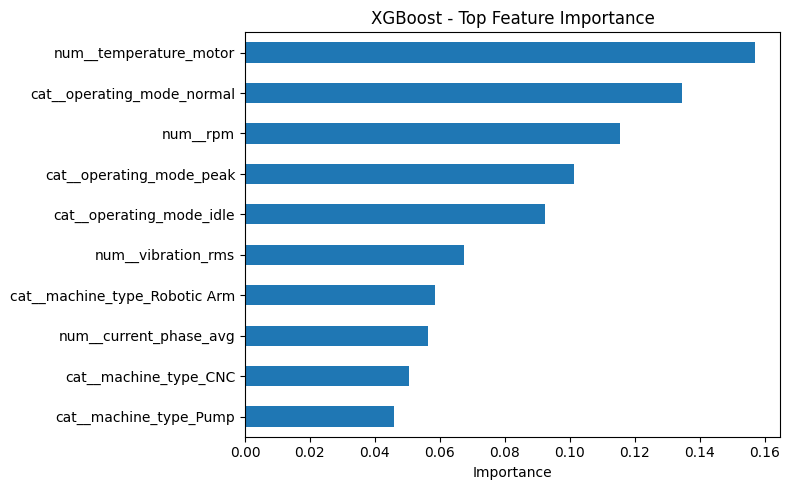


================ SAMPLE PREDICTIONS ================

       vibration_rms  temperature_motor  current_phase_avg  pressure_level  \
16528           1.00              48.11               5.70            45.8   
342             4.34              62.52              16.82            69.5   
20810           0.98              35.87               5.38            44.4   

          rpm  hours_since_maintenance  ambient_temp machine_type  \
16528   755.4                    29.48           8.7   Compressor   
342    2708.5                    15.92           8.5          CNC   
20810   348.9                   299.51          11.2  Robotic Arm   

      operating_mode  Actual  Logistic Regression_Prediction  \
16528           idle       0                               0   
342           normal       1                               1   
20810         normal       0                               0   

       Logistic Regression_Probability  Random Forest_Prediction  \
16528                         

In [1]:
# ============================================================
# Predictive Maintenance - Machine Failure Prediction
# Models: Logistic Regression, Random Forest, XGBoost
# Target: failure_within_24h
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

df = pd.read_csv("predictive_maintenance_v3.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df["failure_within_24h"].value_counts())


# ------------------------------------------------------------
# 2. Features and target
# ------------------------------------------------------------

features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp",
    "machine_type",
    "operating_mode"
]

target = "failure_within_24h"

X = df[features]
y = df[target]


# ------------------------------------------------------------
# 3. Feature types
# ------------------------------------------------------------

numeric_features = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance",
    "ambient_temp"
]

categorical_features = [
    "machine_type",
    "operating_mode"
]


# ------------------------------------------------------------
# 4. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 5. Preprocessing
# ------------------------------------------------------------

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])


# ------------------------------------------------------------
# 6. Class imbalance
# ------------------------------------------------------------

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)


# ------------------------------------------------------------
# 7. Models
# ------------------------------------------------------------

models = {

    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}


# ------------------------------------------------------------
# 8. Train and evaluate
# ------------------------------------------------------------

results = {}
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = pred

    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    print(f"\n{'=' * 20} {name} {'=' * 20}")

    print(classification_report(
        y_test,
        pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))


# ------------------------------------------------------------
# 9. Model comparison
# ------------------------------------------------------------

comparison = pd.DataFrame(results).T

print("\n================ MODEL COMPARISON ================\n")
print(comparison.round(4))

best_model = comparison["F1"].idxmax()

print("\nBest Model:", best_model)


# ------------------------------------------------------------
# 10. Model comparison plot
# ------------------------------------------------------------

comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Predictive Maintenance Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

os.makedirs("results", exist_ok=True)

plt.savefig(
    "results/model_comparison.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 11. Feature importance
# ------------------------------------------------------------

for name in ["Random Forest", "XGBoost"]:

    model = models[name]

    classifier = model.named_steps["model"]
    prep = model.named_steps["prep"]

    feature_names = prep.get_feature_names_out()

    importance = pd.Series(
        classifier.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(10)

    print(f"\n{name} - Top Features:")
    print(importance)

    importance.sort_values().plot(
        kind="barh",
        figsize=(8, 5)
    )

    plt.title(f"{name} - Top Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()

    plt.savefig(
        f"results/{name.lower().replace(' ', '_')}_importance.png",
        dpi=300
    )

    plt.show()


# ------------------------------------------------------------
# 12. Sample predictions
# ------------------------------------------------------------

sample = X_test.iloc[:3].copy()

sample_results = sample.copy()

sample_results["Actual"] = y_test.loc[sample.index].values

for name, model in models.items():

    sample_results[name + "_Prediction"] = model.predict(sample)

    sample_results[name + "_Probability"] = np.round(
        model.predict_proba(sample)[:, 1],
        3
    )

print("\n================ SAMPLE PREDICTIONS ================\n")
print(sample_results)


# ------------------------------------------------------------
# 13. Save results
# ------------------------------------------------------------

comparison.round(4).to_csv(
    "results/model_comparison.csv"
)

sample_results.to_csv(
    "results/sample_predictions.csv",
    index=False
)

print("\nResults saved to the 'results' folder.")